In [1]:
import os
print(os.listdir())

['.config', 'IMDB Dataset.csv', 'sample_data']


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.svm import LinearSVC


In [3]:
df=pd.read_csv(
    "IMDB Dataset.csv",
    engine="python",
    on_bad_lines="skip"
    )
print(df)

                                                  review sentiment
0      One of the other reviewers has mentioned that ...  positive
1      A wonderful little production. <br /><br />The...  positive
2      I thought this was a wonderful way to spend ti...  positive
3      Basically there's a family where a little boy ...  negative
4      Petter Mattei's "Love in the Time of Money" is...  positive
...                                                  ...       ...
20554  This film is one of the best memories I have f...  positive
20555  Compared to director Kevin Connor's later ARAB...  negative
20556  THE SECRET OF KELLS is an astonishing first an...  positive
20557  As I have matured, my fascination with the Aca...  positive
20558  It's partly bad luck for "Illuminata" that it ...  negative

[20559 rows x 2 columns]


In [4]:
print(df.shape)

(20559, 2)


In [5]:
print(df.columns)

Index(['review', 'sentiment'], dtype='object')


In [6]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
df.dtypes

,0
review,object
sentiment,object


In [8]:
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [9]:
print(df.duplicated().sum())

76


In [10]:
print(df["sentiment"].value_counts())

sentiment
negative    10370
positive    10189
Name: count, dtype: int64


In [11]:
print(df["sentiment"].value_counts(normalize=True)*100)

sentiment
negative    50.440197
positive    49.559803
Name: proportion, dtype: float64


In [12]:
duplicates=df[df.duplicated(keep=False)]
print(len(duplicates))

150


In [13]:
print(duplicates["sentiment"].value_counts())

sentiment
negative    104
positive     46
Name: count, dtype: int64


In [14]:
duplicates[["review","sentiment"]].head(10)

,review,sentiment
140,"Before I begin, let me get something off my ch...",negative
219,Ed Wood rides again. The fact that this movie ...,negative
245,I have seen this film at least 100 times and I...,positive
480,From director Barbet Schroder (Reversal of For...,negative
636,I rented this thinking it would be pretty good...,negative
638,This movie has everything typical horror movie...,positive
717,I want very much to believe that the above quo...,negative
744,Sigh. I'm baffled when I see a short like this...,negative
1215,This movie has made me upset! When I think of ...,negative
1233,"Beautiful film, pure Cassavetes style. Gena Ro...",positive


In [15]:
print(
    duplicates["review"].nunique()
)

74


In [16]:
label_conflicts=(
    df.groupby("review")["sentiment"]
    .nunique()
)
(label_conflicts>1).sum()

np.int64(0)

In [17]:
df=df.drop_duplicates().reset_index(drop=True)
print(df.shape)
print(df.duplicated().sum())

(20483, 2)
0


In [18]:
print(df["sentiment"].value_counts())

sentiment
negative    10318
positive    10165
Name: count, dtype: int64


In [19]:
print(df["sentiment"].value_counts(normalize=True)*100)

sentiment
negative    50.37348
positive    49.62652
Name: proportion, dtype: float64


In [20]:
sentiment_counts=df["sentiment"].value_counts()
print(sentiment_counts)

sentiment
negative    10318
positive    10165
Name: count, dtype: int64


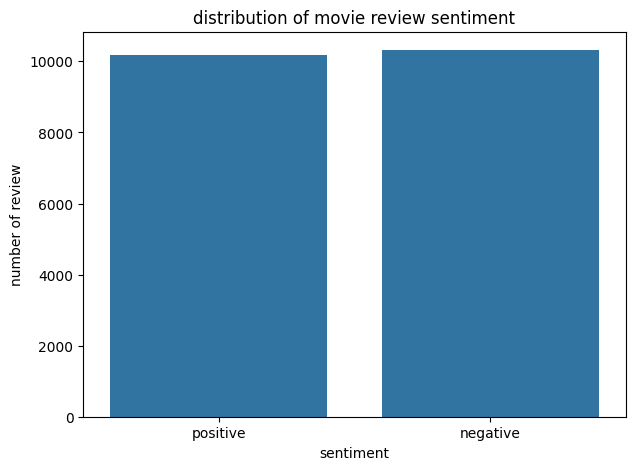

In [21]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="sentiment")
plt.title("distribution of movie review sentiment")
plt.xlabel("sentiment")
plt.ylabel("number of review")
plt.show()

In [22]:
df["review_length"]=df["review"].str.split().str.len()

In [23]:
df[["review","review_length"]].head()

,review,review_length
0,One of the other reviewers has mentioned that ...,307
1,A wonderful little production. <br /><br />The...,162
2,I thought this was a wonderful way to spend ti...,166
3,Basically there's a family where a little boy ...,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",230


In [24]:
df["review_length"].describe()

,review_length
count,20483.000000
mean,231.539911
std,172.340380
min,8.000000
25%,126.000000
50%,172.000000
75%,282.000000
max,1839.000000


In [25]:
df.groupby("sentiment")["review_length"].describe()

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,10318.0,230.541675,166.056862,8.0,128.0,173.0,281.0,1376.0
positive,10165.0,232.553173,178.494883,10.0,124.0,171.0,283.0,1839.0


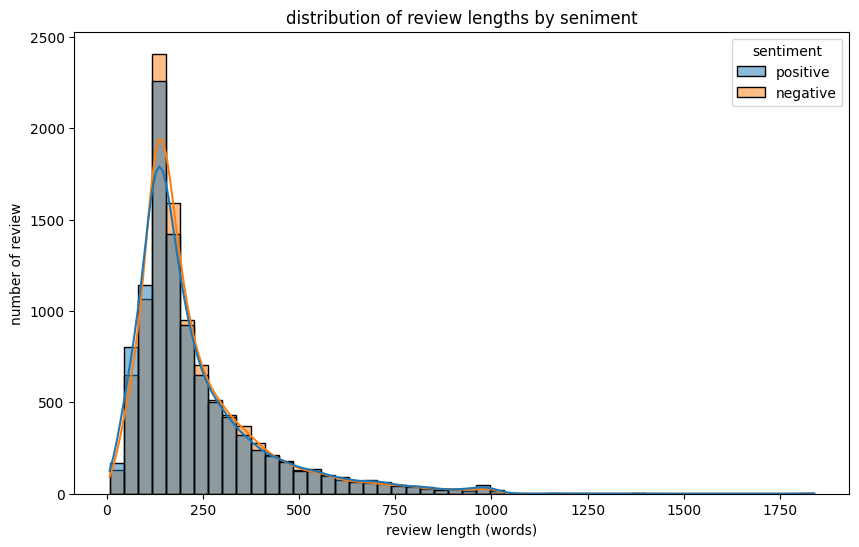

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="review_length",
    hue="sentiment",
    bins=50,
    kde=True
)
plt.title("distribution of review lengths by seniment")
plt.xlabel("review length (words)")
plt.ylabel("number of review")
plt.show()

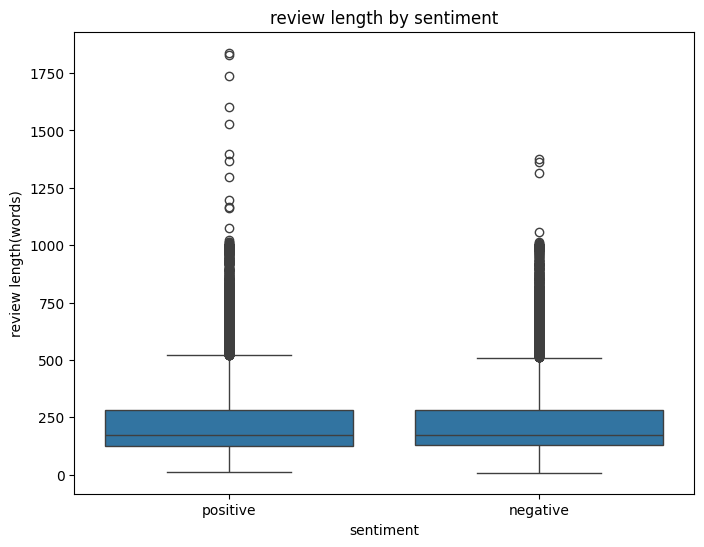

In [27]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="sentiment",
    y="review_length"
)
plt.title("review length by sentiment")
plt.xlabel("sentiment")
plt.ylabel("review length(words)")
plt.show()

In [28]:
length_summary=df.groupby("sentiment")["review_length"].agg(
    mean="mean",
    medial="median",
    min="min",
    max="max"
).round(2)
length_summary

,mean,medial,min,max
sentiment,,,,
negative,230.54,173.0,8,1376
positive,232.55,171.0,10,1839


In [29]:
for i in range(5):
  print(f"\n---Review{i+1}---")
  print(df["review"].iloc[i])
  print("sentiment:",df["sentiment"].iloc[i])


---Review1---
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is

In [30]:
sample_review = df["review"].iloc[0]

cleaned_sample = re.sub(r"<br\s*/?>", " ", sample_review)

print("BEFORE:")
print(sample_review[:500])

print("\nAFTER:")
print(cleaned_sample[:500])

BEFORE:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ

AFTER:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.  The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.  It is called OZ as

In [31]:
lowercase_sample=cleaned_sample.lower()
print("BEFORE:")
print(cleaned_sample[:500])
print("\nAFTER:")
print(lowercase_sample[:500])


BEFORE:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.  The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.  It is called OZ as that is the nick

AFTER:
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.  the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.  it is called oz as

In [32]:
punctuation_sample=lowercase_sample.translate(
    str.maketrans("","",string.punctuation.replace("'",""))

)
print("BEFORE:")
print(lowercase_sample[:500])
print("\nAFTER:")
print(punctuation_sample[:500])

BEFORE:
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.  the first thing that struck me about oz was its brutality and unflinching scenes of violence, which set in right from the word go. trust me, this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs, sex or violence. its is hardcore, in the classic use of the word.  it is called oz as that is the nick

AFTER:
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked they are right as this is exactly what happened with me  the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word  it is called oz as that is th

In [33]:
whitespace_sample = re.sub(r"\s+", " ", punctuation_sample).strip()

print("BEFORE:")
print(punctuation_sample[:500])

print("\nAFTER:")
print(whitespace_sample[:500])

BEFORE:
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked they are right as this is exactly what happened with me  the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word  it is called oz as that is the nickname given 

AFTER:
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the 

In [34]:


test = "One of the other reviewers, has mentioned! this movie."

test = re.sub(r"[^\w\s']", " ", test)

print(test)

One of the other reviewers  has mentioned  this movie 


In [35]:


def clean_text(text):
    text = re.sub(r"<br\s*/?>", " ", text)
    text = text.lower()
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["cleaned_review"] = df["review"].apply(clean_text)

print(df["cleaned_review"].iloc[0][:500])

one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to


In [36]:
df["cleaned_review"]=df["review"].apply(clean_text)

In [37]:
df[["review","cleaned_review","sentiment"]].head(5)

,review,cleaned_review,sentiment
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...,positive
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei's love in the time of money is a...,positive


In [38]:
print(df.shape)

(20483, 4)


In [39]:
x=df["cleaned_review"]
y=df["sentiment"]
print("x shape:",x.shape)
print("y shape:",y.shape
      )

x shape: (20483,)
y shape: (20483,)


In [40]:
y=y.map({
    "negative":0,
    "positive":1
})
print(y.value_counts())

sentiment
0    10318
1    10165
Name: count, dtype: int64


In [41]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("training review:",len(x_train))
print("testing review:",len(x_test))

training review: 16386
testing review: 4097


In [42]:
pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            min_df=2
        )
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [43]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=20000, min_df=2,
                                 ngram_range=(1, 2))),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [44]:
y_pred=pipeline.predict(x_test)
print(y_pred[:10])

[1 1 1 0 1 0 0 0 1 0]


In [45]:
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.8943129118867464


In [46]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.89      2064
           1       0.89      0.90      0.89      2033

    accuracy                           0.89      4097
   macro avg       0.89      0.89      0.89      4097
weighted avg       0.89      0.89      0.89      4097



In [47]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[1842  222]
 [ 211 1822]]


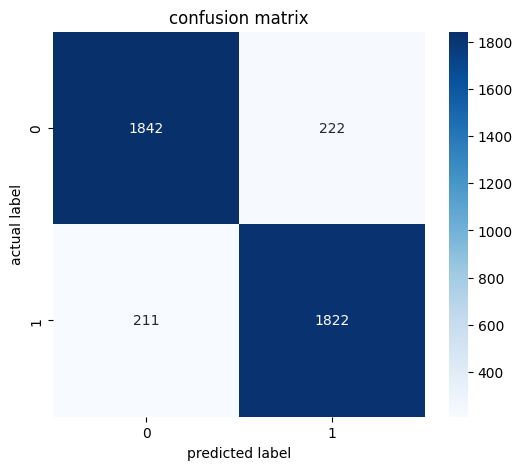

In [48]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("confusion matrix")
plt.xlabel("predicted label")
plt.ylabel("actual label")
plt.show()

In [49]:
y_prob = pipeline.predict_proba(x_test)[:, 1]

print(y_prob[:10])

[0.53808174 0.79155174 0.78926307 0.08439986 0.89554834 0.28407786
 0.19072995 0.15446581 0.58468377 0.05618695]


In [50]:
roc_auc=roc_auc_score(y_test,y_prob)
print(roc_auc)

0.9596402574573797


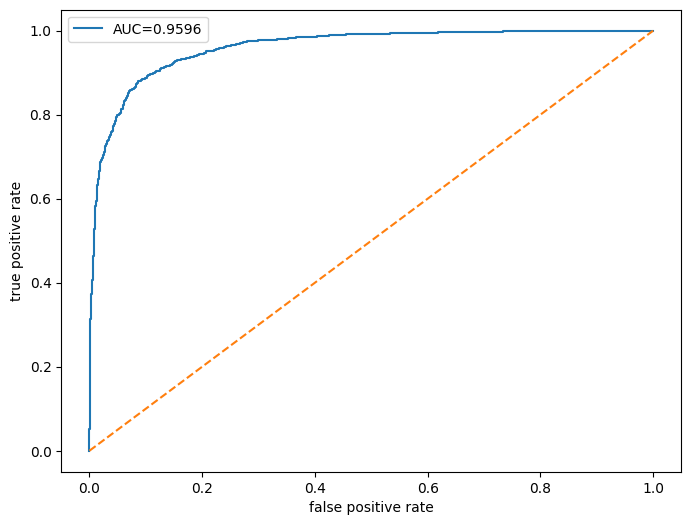

In [51]:
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend()
plt.show()

In [52]:


svc_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=20000,
            ngram_range=(1, 2),
            min_df=2
        )
    ),
    (
        "model",
        LinearSVC(
            random_state=42
        )
    )
])

svc_pipeline.fit(x_train, y_train)

svc_pred = svc_pipeline.predict(x_test)

In [53]:
svc_accuracy=accuracy_score(y_test,svc_pred)
print(svc_accuracy)

0.8930925067122285


In [54]:
print(classification_report(y_test,svc_pred))

              precision    recall  f1-score   support

           0       0.89      0.90      0.89      2064
           1       0.89      0.89      0.89      2033

    accuracy                           0.89      4097
   macro avg       0.89      0.89      0.89      4097
weighted avg       0.89      0.89      0.89      4097



In [55]:
results_df=pd.DataFrame({
    "review":x_test,
    "actual":y_test,
    "predicted":y_pred,
    "probability_positive":y_prob
})
results_df.head()

,review,actual,predicted,probability_positive
1154,others have commented on the somewhat strange ...,1,1,0.538082
15344,bette midler showcases her talents and beauty ...,1,1,0.791552
16709,having watched this film years ago it never fa...,1,1,0.789263
13388,contain spoilers these guys are total scam the...,0,0,0.084400
2760,watching midnight cowboy is like taking a mast...,1,1,0.895548


In [56]:
false_positives = results_df[
    (results_df["actual"] == 0) &
    (results_df["predicted"] == 1)
]

print("False Positives:", len(false_positives))

False Positives: 222


In [57]:
false_negatives = results_df[
    (results_df["actual"] == 1) &
    (results_df["predicted"] == 0)
]

print("False Negatives:", len(false_negatives))

False Negatives: 211


In [58]:
false_positives[
    ["review","actual","predicted","probability_positive"]

].head(5)

,review,actual,predicted,probability_positive
5059,in 1987 john hughes wrote and directed 'planes...,0,1,0.584684
13621,jeez only in the 70's antonio margheriti bring...,0,1,0.631795
2510,this worldwide was the cheap man's version of ...,0,1,0.529054
19929,oddly enough it's fred macmurray who plays the...,0,1,0.789683
16820,if you haven't seen the war at home let me tel...,0,1,0.543911


In [59]:
false_negatives[
    ["review", "actual", "predicted", "probability_positive"]
].head(5)

,review,actual,predicted,probability_positive
20046,its very tough to portray a tagore novel along...,1,0,0.447086
1749,ok maybe posse can't compare to other popular ...,1,0,0.429240
10026,i cannot say this movie is a disappointment be...,1,0,0.459858
16002,young warriors 1983 while this is a deeply fla...,1,0,0.357273
7822,when i saw the movie at first i thought that i...,1,0,0.429260


In [60]:
def predict_sentiment(review_text):

    prediction = pipeline.predict([review_text])[0]
    probability = pipeline.predict_proba([review_text])[0]

    confidence = probability.max()

    return {
        "prediction": "Positive" if prediction == 1 else "Negative",
        "confidence": confidence
    }

In [61]:
result = predict_sentiment(
    "This movie was fantastic!"
)

print(result)

{'prediction': 'Positive', 'confidence': np.float64(0.7466810574682149)}


In [62]:
import joblib

joblib.dump(pipeline, "sentiment_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [63]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 92.2 MB/s eta 0:00:00


In [64]:
import streamlit as st
import joblib

# Load model
model = joblib.load("sentiment_model.pkl")

# App title
st.title("🎬 Movie Review Sentiment Analysis")

st.write(
    """
    Enter a movie review below and the model will predict
    whether the sentiment is Positive or Negative.
    """
)

# User input
review = st.text_area(
    "Enter Movie Review:",
    height=200
)

# Predict button
if st.button("Predict Sentiment"):

    if review.strip() == "":
        st.warning("Please enter a review.")
    else:

        prediction = model.predict([review])[0]

        probabilities = model.predict_proba([review])[0]

        confidence = probabilities.max()

        sentiment = (
            "Positive"
            if prediction == 1
            else "Negative"
        )

        st.subheader("Prediction")

        st.success(
            f"Sentiment: {sentiment}"
        )

        st.write(
            f"Confidence: {confidence:.2%}"
        )

st.markdown("---")

st.caption(
    """
    Disclaimer:
    Predictions may be incorrect for sarcasm,
    mixed opinions, or ambiguous reviews.
    """
)

2026-09-24 05:17:00.001 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:17:00.185 
  command:

    streamlit run /usr/local/lib/python3.13/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-09-24 05:17:00.186 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:17:00.187 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:17:00.190 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:17:00.191 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:17:00.192 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-24 05:17:00.193 Thread 'MainThread': mi

DeltaGenerator()

In [65]:
joblib.dump(pipeline,  "app.py")

['app.py']